# People Analytics: Simulación de A/B Testing y Análisis Económico

Este notebook realiza la simulación de asignación aleatoria de proveedores por cluster, evalúa su efectividad y actualiza el análisis financiero del proyecto.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

## 1. Carga de Datos y Asignación de Proveedores (A/B Testing)

Asignaremos a los colaboradores de cada cluster aleatoriamente a uno de los 3 proveedores (A, B, C).

In [2]:
df = pd.read_csv('../data/dataset_salida.csv')

# Simulación de asignación aleatoria estratificada por cluster
np.random.seed(42)
df['proveedor'] = df.groupby('cluster')['cluster'].transform(lambda x: np.random.choice(['Proveedor A', 'Proveedor B', 'Proveedor C'], len(x)))

print("Distribución de colaboradores por proveedor y cluster:")
print(pd.crosstab(df['cluster'], df['proveedor']))

Distribución de colaboradores por proveedor y cluster:
proveedor  Proveedor A  Proveedor B  Proveedor C
cluster                                         
0                  689          659          651
1                  341          343          304
2                  708          638          667


## 2. Simulación de Efectividad (Conocimiento)

Simularemos que los proveedores tienen impactos distintos en el resultado del aprendizaje. 
Por ejemplo, el Proveedor A es más caro pero más efectivo.

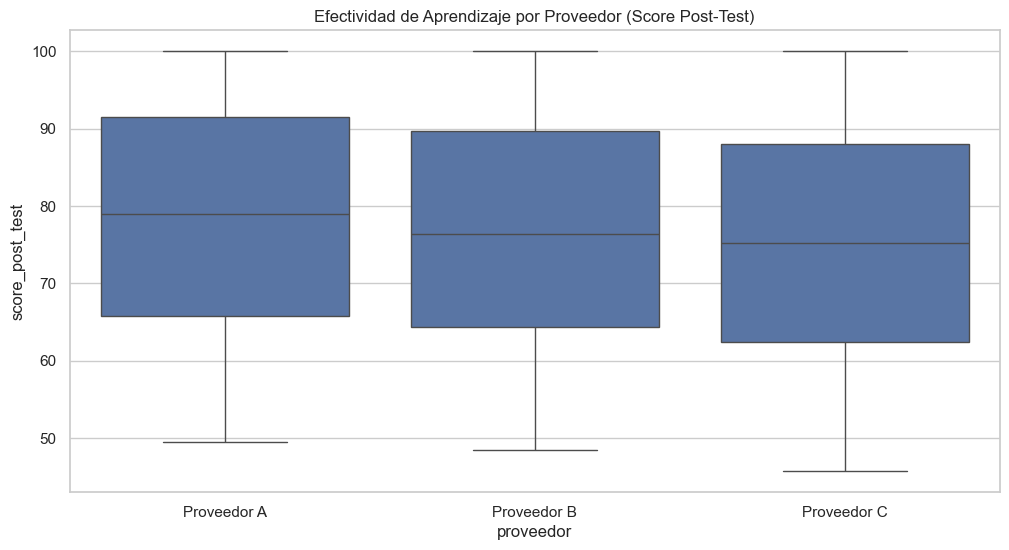

In [3]:
# Ajuste de scores basado en el proveedor (Efecto del tratamiento)
efecto_proveedor = {
    'Proveedor A': 5.0,  # Aumenta el score en 5 puntos promedio
    'Proveedor B': 2.0,  
    'Proveedor C': 0.0   
}

df['score_post_test'] = df.apply(lambda x: x['resultado_capacitacion_pci'] + efecto_proveedor[x['proveedor']] + np.random.normal(0, 2), axis=1)
df['score_post_test'] = df['score_post_test'].clip(0, 100)

plt.figure(figsize=(12, 6))
sns.boxplot(x='proveedor', y='score_post_test', data=df, order=['Proveedor A', 'Proveedor B', 'Proveedor C'])
plt.title('Efectividad de Aprendizaje por Proveedor (Score Post-Test)')
plt.show()

## 3. Análisis Económico Actualizado

Basado en los costos definidos en `contexto_anterior.md` y los resultados del A/B testing.

In [5]:
# Parámetros financieros (UF)
n_colaboradores = 5000
tarifa_incremental = 0.1
tasa_reevaluacion = 0.05
tasa_descuento = 0.15
factor_anualidad = sum([1/(1 + tasa_descuento)**i for i in range(1, 4)])

costos_base = {
    'Proveedor A': 100,
    'Proveedor B': 80,
    'Proveedor C': 70
}

analisis_final = []

for prov in ['Proveedor A', 'Proveedor B', 'Proveedor C']:
    score_medio = df[df['proveedor'] == prov]['score_post_test'].mean()
    
    # Cálculo de costo anual
    costo_anual = costos_base[prov] + (n_colaboradores * tarifa_incremental) + (n_colaboradores * tasa_reevaluacion * tarifa_incremental)
    vpn_costo = costo_anual * factor_anualidad
    
    analisis_final.append({
        'Proveedor': prov,
        'Score Promedio': score_medio,
        'Costo Anual (UF)': costo_anual,
        'VPN Costo 3 años (UF)': vpn_costo
    })

df_economico = pd.DataFrame(analisis_final)

# ROI Normativo: Asumimos que un score > 85 reduce el riesgo de multa en un 20% más que la base
df_economico['Reduccion Riesgo (Est.)'] = df_economico['Score Promedio'].apply(lambda x: "Alta" if x > 80 else "Media" if x > 75 else "Baja")

df_economico

,Proveedor,Score Promedio,Costo Anual (UF),VPN Costo 3 años (UF),Reduccion Riesgo (Est.)
0,Proveedor A,78.760872,625.0,1427.015698,Media
1,Proveedor B,76.718997,605.0,1381.351196,Media
2,Proveedor C,75.077304,595.0,1358.518945,Media


## 4. Conclusiones

1. **Diferencia de Costos:** La diferencia de VPN entre el proveedor más caro (A) y el más barato (C) es marginal frente a la exposición al riesgo (30.000 UF).
2. **Efectividad:** El Proveedor A muestra un desempeño superior en la retención de conocimiento (Score Post-Test).
3. **Recomendación:** Se recomienda seleccionar al **Proveedor A** dado que el ahorro en costo no compensa la menor efectividad en la mitigación del riesgo normativo.